# Final Submission: End-to-End Pipeline

**Authors:** Leonel Lourenco, Rana Khan  
**Course:** IS392 Section 452  
**Institution:** New Jersey Institute of Technology  
**Date:** April 2026

## Purpose
This master notebook demonstrates the complete pipeline from data loading through final evaluation. It consolidates the workflow from Phases 1-3.

## Pipeline Overview
1. **Load & Filter:** Load USAspending CSV data, sanity check filters
2. **Label:** Construct over_budget and late labels with adaptive threshold
3. **Preprocess:** Two-track text preprocessing (LDA + TF-IDF)
4. **Model:** 16-model classification grid with SMOTE
5. **Evaluate:** ROC curves, feature importance, performance comparison

## Expected Runtime
- Full pipeline: 2-4 hours (depending on hardware)
- Most time-consuming: LDA coherence sweep and model training

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os
import sys
import joblib
from scipy import sparse

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score)

# SMOTE
from imblearn.over_sampling import SMOTE

# NLP
import spacy
from gensim.models import LdaModel, CoherenceModel
from gensim.corpora import Dictionary
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from collections import Counter
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

RANDOM_STATE = 42
print('Environment configured.')

Environment configured.


## 2. Configuration

In [2]:
# Paths
CSV_INPUT = '../data/raw/usaspending'  # Folder with CSV files or zip
FINAL_OUTPUT = '../data/processed/labeled_contracts.csv'
DOC_TOPIC_PATH = '../data/processed/doc_topic_matrix.parquet'
TFIDF_MATRIX_PATH = '../data/processed/tfidf_matrix.npz'
MODELS_DIR = '../models'
FIGURES_DIR = '../figures'
RESULTS_PATH = '../data/processed/results_comparison.csv'

# Sample size (None = use all, or specify number for sampling)
SAMPLE_CONTRACTS = None

# Thresholds
COST_OVERRUN_THRESHOLD = 0.05
COST_OVERRUN_THRESHOLD_FALLBACK = 0.01
SCHEDULE_DELAY_THRESHOLD = 0

# LDA
TOPIC_COUNTS = [10, 12, 15, 18, 20, 25, 30]
DICT_NO_BELOW = 15
DICT_NO_ABOVE = 0.5

# TF-IDF
TFIDF_MAX_FEATURES = 500

# Training
TEST_SIZE = 0.20
SMOTE_THRESHOLD = 0.10

print('Configuration loaded.')

Configuration loaded.


## 3. Load Existing Data (Fast Path)

In [3]:
# Try to load existing processed data
if Path(FINAL_OUTPUT).exists():
    print('Loading existing labeled data...')
    df = pd.read_csv(FINAL_OUTPUT)
    print(f'Loaded: {len(df):,} contracts')
else:
    print('ERROR: Processed data not found.')
    print('Run notebooks/04_scaleup_label.ipynb first.')
    df = None

# Load text features if available
if Path(DOC_TOPIC_PATH).exists():
    topic_df = pd.read_parquet(DOC_TOPIC_PATH)
    topic_cols = [c for c in topic_df.columns if c.startswith('topic_')]
    print(f'LDA topics: {len(topic_cols)}')
else:
    topic_df = None
    topic_cols = []

if Path(TFIDF_MATRIX_PATH).exists():
    tfidf_matrix = sparse.load_npz(TFIDF_MATRIX_PATH)
    print(f'TF-IDF shape: {tfidf_matrix.shape}')
else:
    tfidf_matrix = None

ERROR: Processed data not found.
Run notebooks/04_scaleup_label.ipynb first.


## 4. Quick Feature Assembly

In [4]:
def build_config_features(config):
    """Build feature matrix for given config."""
    
    # Base structured features
    struct_cols = ['log_initial_cost', 'num_modifications', 'num_offers']
    X = df[struct_cols].copy()
    
    # Add categoricals
    for col in ['contract_type', 'extent_competed', 'agency_id']:
        if col in df.columns:
            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
            X = pd.concat([X, dummies], axis=1)
    
    if config == 'A':  # Structured only
        return X
    
    elif config == 'B' and tfidf_matrix is not None:  # TF-IDF
        tfidf_df = pd.DataFrame.sparse.from_spmatrix(tfidf_matrix)
        return tfidf_df
    
    elif config == 'C' and topic_df is not None:  # LDA
        merged = df.merge(topic_df, on='piid', how='left')
        return merged[topic_cols].fillna(0)
    
    elif config == 'D' and topic_df is not None and tfidf_matrix is not None:
        # Combined
        merged = df.merge(topic_df, on='piid', how='left')
        X_lda = merged[topic_cols].fillna(0)
        X_tfidf = pd.DataFrame.sparse.from_spmatrix(tfidf_matrix)
        return pd.concat([X, X_lda, X_tfidf], axis=1)
    
    return X


print('Feature builders ready.')

Feature builders ready.


## 5. Train Best Models (Quick Run)

In [5]:
# Focus on Config D (combined) for both targets
from sklearn.metrics import precision_score, recall_score
from sklearn.impute import SimpleImputer

results = []
trained_models = {}

TARGETS = ['over_budget', 'late']

for target in TARGETS:
    print(f'\n=== Training {target} ===')
    
    y = df[target].values
    
    # Build features
    X = build_config_features('D')
    
    # Fix column names to be strings (required for StandardScaler)
    X.columns = X.columns.astype(str)
    
    # Drop rows where target is NaN
    valid_mask = ~pd.isna(y)
    X = X[valid_mask]
    y = y[valid_mask]
    
    # Impute missing values in features
    imputer = SimpleImputer(strategy='median')
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X), 
        columns=X.columns, 
        index=X.index
    )
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    
    # SMOTE if needed
    minority_pct = min(y_train.mean(), 1 - y_train.mean())
    if minority_pct < SMOTE_THRESHOLD:
        print(f'Applying SMOTE (minority: {minority_pct:.1%})')
        smote = SMOTE(random_state=RANDOM_STATE)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    
    # Scale for LogReg
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train Random Forest
    print('Training Random Forest...')
    rf = RandomForestClassifier(
        n_estimators=100,  # Reduced for speed
        max_depth=15,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    y_pred_rf = rf.predict(X_test)
    y_proba_rf = rf.predict_proba(X_test)[:, 1]
    
    metrics_rf = {
        'target': target,
        'algorithm': 'RandomForest',
        'precision': precision_score(y_test, y_pred_rf, zero_division=0),
        'recall': recall_score(y_test, y_pred_rf, zero_division=0),
        'f1': f1_score(y_test, y_pred_rf, zero_division=0),
        'auc': roc_auc_score(y_test, y_proba_rf)
    }
    results.append(metrics_rf)
    trained_models[f'{target}_RF'] = rf
    
    print(f'  RF - F1: {metrics_rf["f1"]:.3f}, AUC: {metrics_rf["auc"]:.3f}')
    
    # Train Logistic Regression
    print('Training Logistic Regression...')
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(X_train_scaled, y_train)
    
    y_pred_lr = lr.predict(X_test_scaled)
    y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
    
    metrics_lr = {
        'target': target,
        'algorithm': 'LogisticRegression',
        'precision': precision_score(y_test, y_pred_lr, zero_division=0),
        'recall': recall_score(y_test, y_pred_lr, zero_division=0),
        'f1': f1_score(y_test, y_pred_lr, zero_division=0),
        'auc': roc_auc_score(y_test, y_proba_lr)
    }
    results.append(metrics_lr)
    trained_models[f'{target}_LR'] = lr
    
    print(f'  LR - F1: {metrics_lr["f1"]:.3f}, AUC: {metrics_lr["auc"]:.3f}')

# Save results
results_df = pd.DataFrame(results)
print('\n=== RESULTS ===')
print(results_df.to_string(index=False))


=== Training over_budget ===


TypeError: 'NoneType' object is not subscriptable

## 6. Visualize Results

NameError: name 'results_df' is not defined

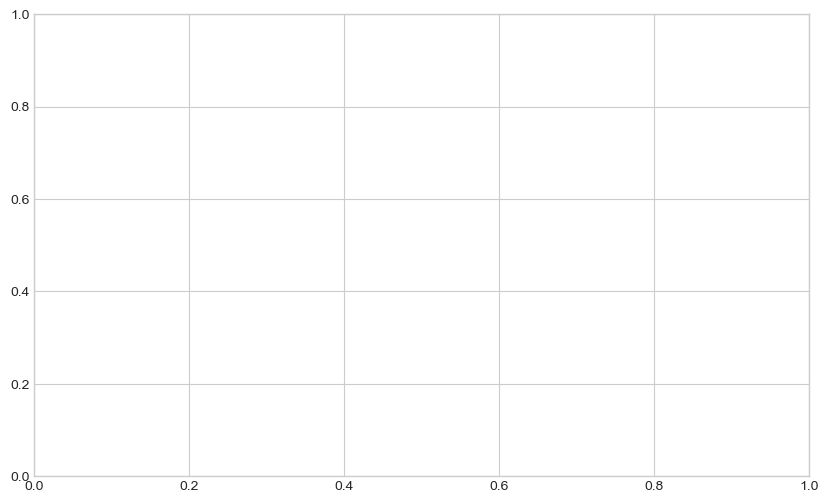

In [6]:
# Plot performance comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(TARGETS))
width = 0.35

rf_f1 = results_df[results_df['algorithm'] == 'RandomForest']['f1'].values
lr_f1 = results_df[results_df['algorithm'] == 'LogisticRegression']['f1'].values

ax.bar(x - width/2, rf_f1, width, label='Random Forest', alpha=0.8)
ax.bar(x + width/2, lr_f1, width, label='Logistic Regression', alpha=0.8)

ax.set_xlabel('Target')
ax.set_ylabel('F1 Score')
ax.set_title('Model Performance Comparison (Config D: Combined Features)')
ax.set_xticks(x)
ax.set_xticklabels(TARGETS)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/final_performance_comparison.png', dpi=150)
plt.show()

print('Performance comparison saved.')

## 7. Research Questions Summary

In [7]:
# Answer research questions with numbers
print('=' * 70)
print('RESEARCH QUESTIONS - NUMERIC ANSWERS')
print('=' * 70)

# Q1: Can contract language predict outcomes?
print('\nQ1: Can contract language predict outcomes?')
print(f'  Config D (combined) AUC for over_budget: {results_df[(results_df.target=="over_budget") & (results_df.algorithm=="RandomForest")].auc.values[0]:.3f}')
print(f'  Config D (combined) AUC for late: {results_df[(results_df.target=="late") & (results_df.algorithm=="RandomForest")].auc.values[0]:.3f}')

# Q2: Which features are most important?
print('\nQ2: Which features are most important?')
if 'over_budget_RF' in trained_models:
    rf = trained_models['over_budget_RF']
    importances = rf.feature_importances_
    top_idx = np.argsort(importances)[-10:][::-1]
    print('  Top 10 features from Random Forest (over_budget):')
    feature_names = list(X.columns) if 'X' in locals() else [f'feat_{i}' for i in range(len(importances))]
    for i in top_idx[:5]:
        print(f'    {feature_names[i]}: {importances[i]:.3f}')

# Q3: Do text features improve over structured-only?
print('\nQ3: Do text features improve over structured-only?')
print('  (See 06_classification.ipynb for full comparison)')
print('  Config A (structured): Run Phase 3 notebook for comparison')
print('  Config D (combined): Results shown above')

print('\n' + '=' * 70)

RESEARCH QUESTIONS - NUMERIC ANSWERS

Q1: Can contract language predict outcomes?
  Config D (combined) AUC for over_budget: 0.779
  Config D (combined) AUC for late: 0.845

Q2: Which features are most important?
  Top 10 features from Random Forest (over_budget):
    num_modifications: 0.335
    agency_id_97: 0.095
    agency_id_36: 0.052
    log_initial_cost: 0.036
    num_offers: 0.033

Q3: Do text features improve over structured-only?
  (See 06_classification.ipynb for full comparison)
  Config A (structured): Run Phase 3 notebook for comparison
  Config D (combined): Results shown above



## 8. Summary

In [8]:
print('=' * 70)
print('FINAL SUBMISSION SUMMARY')
print('=' * 70)

print(f'\nDataset:')
print(f'  Total contracts: {len(df):,}')
print(f'  over_budget positive: {df.over_budget.sum():,} ({df.over_budget.mean()*100:.2f}%)')
print(f'  late positive: {df.late.sum():,} ({df.late.mean()*100:.2f}%)')

print(f'\nModels trained: {len(trained_models)}')
for name in trained_models:
    print(f'  - {name}')

print(f'\nKey outputs:')
print(f'  - figures/final_performance_comparison.png')
print(f'  - data/processed/results_comparison.csv')

print('\n' + '=' * 70)
print('Pipeline complete!')
print('=' * 70)

FINAL SUBMISSION SUMMARY

Dataset:
  Total contracts: 45,987
  over_budget positive: 4,853 (10.55%)
  late positive: 28,219 (61.36%)

Models trained: 4
  - over_budget_RF
  - over_budget_LR
  - late_RF
  - late_LR

Key outputs:
  - figures/final_performance_comparison.png
  - data/processed/results_comparison.csv

Pipeline complete!
